# TSCAN_FT | EfficientPhys_FT | PhysFormer_FT - Fine-Tuning Strategy: Head-Only

**Strategy**: Backbone is **completely frozen**. Only the final regression head is trained. 

### What this experiment tests

Given that previous experiment (weight transfer) was near-zero (0.2-12.3% from JAX->PyTorch shape matching), head-only here test a different hypothesis:

>*Can the frozen 1D architecture's internal representations, initialised randomly  but with the structural inductive biases of TSCAN/EfficientPhys/PhysFormer,
 produce useful features for a shallow head without any backbone adaptation?*
>

If head-only wins or ties, it means the architecture itself (not the weights) carries the performance.

### EfficientPhys, bias correction
Full fine-tuning revealed EfficientPhys learns relative HR ranking perfectly (r=0.9777) but produces a +11.95 BPM systematic offset. Root cause: Optuna drove `lr_backbone` near zero -> backbone never calibrated absolute output scale.

In head-only, the backbone is **frozen by design** - the same risk applies. **Bias penalty** added to the Optuna objective is being adressing it.

```
objective = val_MAE + α × max(0, |mean(preds) − mean(labels)| − tolerance)
```

`α = 0.5`, `tolerance = 2.0 BPM` — penalty activates only when bias exceeds 2 BPM.

### Comparison goal
```
Head-Only  vs Full Fine-Tune  vs Scratch 
```
The three-way table at the end closes the fine-tuning strategy comparison.

## 1. Imports and Configs 

In [1]:
!pip install -q open-rppg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 MB 24.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 84.6 MB/s eta 0:00:00


In [ ]:
import h5py, torch, os, optuna, pkg_resources, warnings
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy import stats
from scipy.signal import resample
from dataclasses import dataclass
from collections import defaultdict
from tqdm import tqdm
from typing import Callable
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Fixed config - never tuned

H5_PATHS = {
    "ubfc_phys" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ubfc_phys.h5",
    "ubfc_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ubfc_rppg.h5",
    "ecg_fitness" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ecg_fitness.h5",
    "mcd_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/mcd_rppg.h5",
}

HR_MIN = 40.0
HR_MAX = 180.0 
MAX_NAN_FRAC = 0.10
TARGET_FRAMES = 240
WINDOW_SEC = 8
STRIDE_SEC = 4
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Tuning config
N_TRIALS = 50
N_EPOCHS = 50
BATCH_SIZE = 32
PRUNER_WARMUP = 5
WEIGHTS_DIR = pkg_resources.resource_filename("rppg", "weights")

# EfficientPhys bias correction hyperparameters
BIAS_PENALTY_ALPHA = 0.5 # weight of bias term in objective
BIAS_PENALTY_TOLERANCE = 2.0 # BPM - penalty only activates beyond this
print(f"Device: {DEVICE}")

print(f"Trials : {N_TRIALS} | Max epochs/trials {N_EPOCHS}")
print(f"Weights dir : {WEIGHTS_DIR}")

/tmp/ipykernel_23/1459739805.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import h5py, torch, os, optuna, pkg_resources, warnings


Device: cuda
Trials : 50 | Max epochs/trials 50
Weights dir : /usr/local/lib/python3.12/dist-packages/rppg/weights


## 2. Window Extractor

In [ ]:
def extract_windows(rppg: np.ndarray, hr_cont: np.ndarray, fps: float, window_sec: int, stride_sec: int, 
                    target_frames: int, max_nan_frac: float, hr_min: float, hr_max: float) -> tuple:
    """
    Extract sliding windows from one recording.

    Returns:
        windows : list of np.ndarray, each shape (target_frames,)
        labels : list of float, HR in BPM
    """
    window_frames = int(fps * window_sec)
    stride_frames = int(fps * stride_sec)
    n_frames = len(rppg)

    windows  = []
    labels  = []

    for start in range(0, n_frames - window_frames + 1, stride_frames):
        end = start + window_frames

        rppg_win = rppg[start:end]
        hr_win = hr_cont[start:end]

        # NaN check on label
        nan_frac = np.sum(np.isnan(hr_win)) / len(hr_win)
        if nan_frac > max_nan_frac:
            continue
        
        # Compute scalar HR label
        hr_label = float(np.nanmean(hr_win))

        # Physiological sanity check
        if not (hr_min <= hr_label <= hr_max):
            continue

        # NaN check on signal
        if np.any(np.isnan(rppg_win)):
            continue

        # Resample to fixed length
        if len(rppg_win) != target_frames:
            rppg_win = resample(rppg_win, target_frames).astype(np.float32)

        # Z-score normalisation per window
        std = rppg_win.std()
        if std < 1e-6:
            continue
        rppg_win = (rppg_win - rppg_win.mean()) / std

        windows.append(rppg_win.astype(np.float32))
        labels.append(hr_label)

    return windows, labels

## 3. Index Builder 

In [4]:
def build_index(h5_paths : dict[str, str], window_sec: int, stride_sec: int, target_frames: int,
                max_nan_frac: float, hr_min: float, hr_max: float) -> tuple:
    """
    Returns: 
        samples : list of dicts with keys: signal, hr_label, subject_key, dataset
        subject_keys : sorted list of unique subject identifiers (dataset + subject_id)
    """
    samples = []
    subject_keys = set()

    for dataset_name, path in h5_paths.items():
        with h5py.File(path, "r") as file:
            subjects = file["subjects"]

            for subj_id in subjects.keys():
                subj_key = f"{dataset_name}__{subj_id}"
                subject_keys.add(subj_key)
                recordings = subjects[subj_id]["recordings"]

                for sess_id in recordings.keys():
                    rec = recordings[sess_id]
                    fps = float(rec.attrs["fps"])
                    rppg = rec["rppg_signal"][:]
                    hr = rec["hr_continuous"][:]

                    wins, labels = extract_windows(rppg, hr, fps, window_sec,
                                                stride_sec, target_frames,
                                                max_nan_frac, hr_min, hr_max)

                    for win, label in zip(wins, labels):
                        samples.append({
                            "signal" : win,
                            "hr_label" : label,
                            "subject_key" : subj_key,
                            "dataset" : dataset_name
                        })

    print(f"Total windows extracted : {len(samples)}")
    print(f"Total unique subjects : {len(subject_keys)}")
    return samples, sorted(subject_keys)

## 4. Subject-Level Split

In [5]:
def subject_split(subject_keys: list[str], train_frac: float = 0.70,  val_frac: float = 0.15, seed : int = 42) -> tuple:
    """
    Returns three sets of subject_key strings.
    test_frac = 1 - train_frac - val_frac.
    """
    rng = np.random.default_rng(seed)
    keys = np.array(subject_keys)
    rng.shuffle(keys)

    n = len(keys)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_keys : set[str] = set(keys[:n_train])
    val_keys : set[str] = set(keys[n_train : n_train + n_val])
    test_keys : set[str] = set(keys[n_train + n_val :])

    print(f"Train subjects : {len(train_keys)}")
    print(f"Val subjects : {len(val_keys)}")
    print(f"Test subjects : {len(test_keys)}")
    return train_keys, val_keys, test_keys

## 5. Dataset

In [6]:
class CRVSEDataset(Dataset):
    """
    PyTorch Dataset for CRVSE Phase 2 rPPG -> HR estimation.
    
    Args: 
        samples : list of dicts from build_index()
        subject_set : set of subject_key strings to include (train/val/test)
    """
    def __init__(self, samples: list[dict], subject_set: set[str]) -> None:
        self.items: list[dict] = [sample for sample in samples if sample["subject_key"] in subject_set]
        print(f"Dataset size: {len(self.items)} windows")

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        item = self.items[idx]
        signal = torch.tensor(item["signal"], dtype=torch.float32).unsqueeze(0)
        # shape: (1, TARGET_Framse) - (channels, time)
        label = torch.tensor(item["hr_label"], dtype=torch.float32)
        return signal, label 


## 6. Architectures (1D Adaptations)

In [7]:
class TSM1D(nn.Module):
    """
    Temporal Shift Module - 1D signal version.
    
    Shifts fold_div_th of channels backward (use past timestep) and another 
    fold_div_th forward (use future timestep), leaving the rest unchanged.
    Zero-cost temporal ocntext expansion.
    
    Args:
        n_channels : umber of feature channels (C)
        fold_div : 1/fold_div of channels are shifted each direction
    """
    def __init__(self, n_channels: int, fold_div: int = 8) -> None:
        super().__init__()
        self.fold = max(1, n_channels // fold_div)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T)
        B, C, T = x.shape
        fold = self.fold
        out = x.clone()
        # Shift first fold channels backward (past -> current)
        out[:, :fold, 1:] = x[:, :fold, :-1]
        out[:, :fold, :1] = x[:, :fold, :1] # pad boundary
        # Shift second fold channels forward (future -> current)
        out[:, fold:2*fold, :-1] = x[:, fold:2*fold, 1:]
        out[:, fold:2*fold, -1:] = x[:, fold:2*fold, -1:] # pad boundary
        return out

### Model: TSCAN_FT

In [8]:
class TSCAN_FT(nn.Module):
    """
    1D adaptation of TSCAN (Temporal Shift Convolutional Attention Network).

    Original two-stream design:
        Appearance stream : processes raw frames
        Motion stream : processes difference frames
        Cross-attention : appearance weights gate motion output

    1D adaptation:
        Appearance stream : processes rPPG signal x
        Motion stream : processes diff signal  Δx[t] = x[t] − x[t−1]
        Temporal Shift : applied to appearance features (TSM)
        Cross-attention : appearance-derived sigmoid weights gate motion

    Pretrained weight transfer:
        Attention linear (if base_channels=64 matches pretrained)
        LayerNorm/BN     (1D statistics, shape-matched)
    Skiped:
        CNN blocks (2D -> 1D shape mismatch)
    """
    def __init__(self, in_channels: int = 1, base_channels: int = 128, dropout: float = 0.2,
                 hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()
        self.hr_min = hr_min
        self.hr_max = hr_max
        C = base_channels

        # Appearance stream 
        self.appearance = nn.Sequential(
            nn.Conv1d(in_channels, C // 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(C // 2), nn.Tanh(),
            nn.Conv1d(C // 2, C, kernel_size=3, padding=1),
            nn.BatchNorm1d(C), nn.Tanh(),
            nn.Conv1d(C, C, kernel_size=3, padding=1),
            nn.BatchNorm1d(C), nn.Tanh(),
        )

        # Temporal Shift Module
        self.tsm = TSM1D(C, fold_div=8)

        # Attention head
        self.attention = nn.Sequential(nn.Conv1d(C, C, kernel_size=1), nn.BatchNorm1d(C), nn.Sigmoid())

        # Motion (difference) stream 
        self.motion = nn.Sequential(
            nn.Conv1d(in_channels, C // 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(C // 2), nn.Tanh(),
            nn.Conv1d(C // 2, C, kernel_size=3, padding=1),
            nn.BatchNorm1d(C), nn.Tanh(),
            nn.Conv1d(C, C, kernel_size=3, padding=1),  
            nn.BatchNorm1d(C), nn.Tanh(), 
        )

        self.dropout = nn.Dropout(dropout)

        # Regression head
        self.head = nn.Sequential(nn.Linear(C, 32), nn.ELU(), nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 1, T)
        # Compute difference signal (motion analog)
        diff = torch.zeros_like(x)
        diff[:, :, 1:] = x[:, :, 1:] - x[:, :, :-1]

        # Appearance stream -> TSM -> attention weights
        app = self.appearance(x) # (B, C, T)
        app = self.tsm(app) # temporal shift
        weights = self.attention(app) # (B, C, T)  ∈ [0,1]

        # Motion stream gated by appearance attention
        mot = self.motion(diff) # (B, C, T)
        out = mot * weights # element-wise gating
        out = self.dropout(out)

        out = out.mean(dim=-1) # (B, C)  global avg pool
        out = self.head(out).squeeze(-1) # (B,)

        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out

### Model: EfficientPhys_FT

In [9]:
class EfficientPhys_FT(nn.Module):
    """
    1D adaptation of EfficientPhys (Efficient Self-Attention TSCAN).

    Key change vs TSCAN: replaces cross-stream attention with
    self-attention on the temporally-shifted features.
    More parameter-efficient. Captures long-range temporal dependencies
    within a single stream.

    1D adaptation:
        CNN encoder : extracts local pulse features from rPPG signal
        TSM : zero-cost temporal context expansion
        Self-attention : multi-head attention along time axis
        FFN : position-wise feed-forward

    Pretrained weight transfer:
        Self-attn Q/K/V (linear, if base_channels matches d_model)
        FFN linear layers (shape-matched)
        LayerNorm  (shape-matched)
    Skiped:
        CNN blocks (2D->1D)
    """
    def __init__(self, in_channels: int  = 1, base_channels: int = 64, n_heads: int = 4, dropout: float = 0.2, 
                 hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()
        assert base_channels % n_heads == 0, "base_channels must be divisible by n_heads"
        self.hr_min = hr_min
        self.hr_max = hr_max
        C = base_channels

        # CNN encoder 
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, C // 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(C // 2), nn.ELU(), nn.Dropout(dropout),
            nn.Conv1d(C // 2, C, kernel_size=3, padding=1),
            nn.BatchNorm1d(C), nn.ELU(), nn.Dropout(dropout),
            nn.Conv1d(C, C, kernel_size=3, padding=1),
            nn.BatchNorm1d(C), nn.ELU(),
        )

        # Temporal Shift
        self.tsm = TSM1D(C, fold_div=8)

        # Self-Attention block (pre-norm) 
        self.norm1 = nn.LayerNorm(C)
        self.self_attn = nn.MultiheadAttention(embed_dim=C, num_heads=n_heads, dropout=dropout, batch_first=True)

        # Feed-Forward block (pre-norm)
        self.norm2 = nn.LayerNorm(C)
        self.ffn = nn.Sequential(nn.Linear(C, C * 4), nn.GELU(), nn.Dropout(dropout), nn.Linear(C * 4, C))

        self.dropout = nn.Dropout(dropout)

        # Regression head
        self.head = nn.Sequential(nn.Linear(C, 32), nn.ELU(), nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 1, T)
        out = self.encoder(x) # (B, C, T)
        out = self.tsm(out) # temporal shift

        out = out.permute(0, 2, 1) # (B, T, C)

        # Self-attention with residual (pre-norm)
        res = out
        out = self.norm1(out)
        attn_out, _ = self.self_attn(out, out, out)
        out = res + self.dropout(attn_out)

        # FFN with residual (pre-norm)
        res = out
        out = self.ffn(self.norm2(out))
        out = res + self.dropout(out)

        out = out.mean(dim=1) # (B, C)  global avg pool over time
        out = self.head(out).squeeze(-1) # (B,)

        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out

### Model: PhysFormer_FT

In [10]:
class TemporalDifferenceLayer(nn.Module):
    """
    Temporal Difference Layer - PhysFormer's core innovation.

    At each position, augments the feature with its first-order temporal
    difference: f_td[t] = f[t] + (f[t] - f[t-1]).
    Sharpens quasi-periodic pulse patterns; directly analogous to rPPG
    signal differentiation that enhances peak-to-peak contrast.
    """
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, C)
        diff = torch.zeros_like(x)
        diff[:, 1:, :] = x[:, 1:, :] - x[:, :-1, :]
        return x + diff


class PhysFormer_FT(nn.Module):
    """
    1D adaptation of PhysFormer (Temporal Difference Transformer).

    Why PhysFormer wins vs vanilla Transformer (confirmed in our Round 3):
    The frequency supervision head acts as an anchor — it penalises the
    model for attending to non-physiological frequencies, preventing the
    systematic HR overestimation seen in CRVSETransformer and LocalAttention.

    1D adaptation:
        CNN encoder : extracts local pulse features (1D)
        Frequency branch : FFT magnitude -> compact freq descriptor
        Temporal Difference : applied before each transformer layer
        Transformer : standard multi-head self-attention (pre-norm)
        Frequency head : auxiliary regression from freq features (training only)

    Pretrained weight transfer:
        V projection (linear (96,96) -> transferable if d_model=96)
        Out projection (linear (96,96))
        FFN linear layers
        LayerNorm statistics
        Transfer coverage ~ 25–35%

    Skiped:
        CNN encoder (3D->1D)
        Q, K projections (original uses CDC, a 3D centre-difference conv)

    Training loss:
        L = L_HR_main + lambda_freq × L_HR_freq
        lambda_freq anneals from 1.0 → 0.0 over training
        (forces the model to use frequency information early, then relaxes)
    """
    def __init__(self, in_channels: int = 1, cnn_channels: int = 64, freq_channels: int = 32, n_heads: int = 4, n_layers: int = 2,
                 dim_feedforward: int = 256, dropout: float = 0.2, hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()
        # d_model = cnn_channels + freq_channels, snapped to n_heads divisibility
        d_model = cnn_channels + freq_channels
        d_model = (d_model // n_heads) * n_heads
        freq_channels = d_model - cnn_channels # recompute after snap

        self.hr_min = hr_min
        self.hr_max = hr_max
        self.d_model = d_model
        self.cnn_channels = cnn_channels
        self.freq_channels = freq_channels

        # CNN temporal encoder 
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, cnn_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(cnn_channels), nn.ELU(), nn.Dropout(dropout),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_channels), nn.ELU(), nn.Dropout(dropout),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels), nn.ELU(),
        )

        # Frequency branch
        # FFT magnitude -> compact representation of dominant frequency
        n_fft = TARGET_FRAMES // 2 + 1 # 121 for T=240
        self.freq_encoder = nn.Sequential(
            nn.Linear(n_fft, freq_channels * 2), nn.ELU(), 
            nn.Linear(freq_channels * 2, freq_channels), nn.ELU())

        # Input projection to d_model 
        self.input_proj = nn.Linear(cnn_channels + freq_channels, d_model)

        # Temporal Difference Layer 
        self.td_layer = TemporalDifferenceLayer()

        # Transformer encoder (pre-norm)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True, # Pre-norm — more stable on small datasets
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Main HR regression head 
        self.head = nn.Sequential(nn.Linear(d_model, 64), nn.ELU(), nn.Dropout(dropout), nn.Linear(64, 1))

        # Frequency supervision head 
        # Auxiliary head predicting HR from frequency features only.
        # Active during training - anchors the model to physiological frequencies.
        # Prevents the systematic overestimation seen in CRVSETransformer.
        self.freq_head = nn.Sequential(nn.Linear(freq_channels, 32), nn.ELU(), nn.Linear(32, 1))

    def forward(self, x: torch.Tensor) -> tuple | torch.Tensor:
        # x: (B, 1, T)
        B, _, T = x.shape

        # CNN temporal features
        cnn_out = self.encoder(x) # (B, cnn_C, T)

        # Frequency features (global: one vector per window)
        fft_mag = torch.abs(torch.fft.rfft(x.squeeze(1), dim=-1)) # (B, T//2+1)
        freq_feat = self.freq_encoder(fft_mag) # (B, freq_C)
        freq_exp = freq_feat.unsqueeze(2).expand(-1, -1, T) # (B, freq_C, T)

        # Combine and project
        combined = torch.cat([cnn_out, freq_exp], dim=1) # (B, cnn+freq, T)
        combined = combined.permute(0, 2, 1) # (B, T, C)
        combined = self.input_proj(combined) # (B, T, d_model)

        # Temporal difference -> transformer
        combined = self.td_layer(combined) # sharpens pulse
        out = self.transformer(combined) # (B, T, d_model)
        out = out.mean(dim=1) # (B, d_model)

        hr_main = self.head(out).squeeze(-1) # (B,)
        hr_freq = self.freq_head(freq_feat).squeeze(-1) # (B,) auxiliary

        if not self.training:
            return hr_main.clamp(self.hr_min, self.hr_max)

        return hr_main, hr_freq   # training returns both for combined loss

In [11]:
def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


dummy = torch.randn(4, 1, TARGET_FRAMES)
print("Architecture sanity check")
print("─" * 50)
for name, cls, kwargs in [
    ("TSCAN_FT", TSCAN_FT, dict(base_channels=128)),
    ("EfficientPhys_FT", EfficientPhys_FT, dict(base_channels=64, n_heads=4)),
    ("PhysFormer_FT", PhysFormer_FT, dict(cnn_channels=64, freq_channels=32, n_heads=4, n_layers=2, dim_feedforward=256)),
]:
    m = cls(**kwargs, hr_min=HR_MIN, hr_max=HR_MAX); m.eval()
    with torch.no_grad():
        out = m(dummy)
    if isinstance(out, tuple): out = out[0]
    print(f"{name:<22} | params: {count_parameters(m):>8,} | output: {tuple(out.shape)}")


Architecture sanity check
──────────────────────────────────────────────────
TSCAN_FT               | params:  170,689 | output: (4,)
EfficientPhys_FT       | params:   71,105 | output: (4,)
PhysFormer_FT          | params:  234,626 | output: (4,)


## 7. Pretrained Weight Loader

In [12]:
def load_pretrained_partial(model, h5_path, verbose=True):
    if not os.path.exists(h5_path):
        if verbose: print(f"Weight file not found: {h5_path} -> random init")
        return 0.0
    shape_to_arrays = defaultdict(list)
    with h5py.File(h5_path, "r") as file:
        def collect(name, obj):
            if hasattr(obj, "shape") and len(obj.shape) >= 1:
                arr = np.array(obj, dtype=np.float32)
                shape_to_arrays[arr.shape].append(arr)
        file.visititems(collect)
    own_sd = model.state_dict()
    new_sd = {}
    matched = 0
    total = sum(p.numel() for p in own_sd.values())
    shape_used = defaultdict(int)
    for name, param in own_sd.items():
        shape = tuple(param.shape)
        idx = shape_used[shape]
        cands = shape_to_arrays.get(shape, [])
        if idx < len(cands):
            new_sd[name] = torch.from_numpy(cands[idx])
            shape_used[shape] += 1
            matched += param.numel()
        else:
            new_sd[name] = param
    model.load_state_dict(new_sd)
    frac = matched / total if total > 0 else 0.0
    if verbose:
        print(f"Pretrained transfer: {matched:,} / {total:,} params = {frac*100:.1f}%")
    return frac


ARCH_REGISTRY = {
    "TSCAN_FT": {
        "cls" : TSCAN_FT,
        "kwargs": dict(base_channels=128),
        "h5" : "TSCAN.pure.weights.h5",
    },
    "EfficientPhys_FT": {
        "cls" : EfficientPhys_FT,
        "kwargs" : dict(base_channels=64, n_heads=4),
        "h5" : "EfficientPhys.pure.weights.h5",
    },
    "PhysFormer_FT": {
        "cls" : PhysFormer_FT,
        "kwargs" : dict(cnn_channels=64, freq_channels=32, n_heads=4, n_layers=2, dim_feedforward=256),
        "h5" : "PhysFormer.pure.weights.h5",
    },
}


## 8. Head-Only Freezee Strategy

In [ ]:
def freeze_backbone(model: nn.Module) -> int:
    """
    Freeze all parameters except model.head (and model.freq_head if present).
    Returns number of trainable parameters after freezing.
    """
    # First freeze everything
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze head
    for param in model.head.parameters():
        param.requires_grad = True

    # Unfreeze freq_head if present (PhysFormer_FT auxiliary head)
    if hasattr(model, "freq_head"):
        for param in model.freq_head.parameters():
            param.requires_grad = True

    n_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return n_trainable




# Verify freeze counts
print("Head-only trainable parameter counts after freezing:")
print("─" * 50)
for arch_name, cfg in ARCH_REGISTRY.items():
    model = cfg["cls"](**cfg["kwargs"], dropout=0.2, hr_min=HR_MIN, hr_max=HR_MAX)
    total = count_parameters(model)
    trainable = freeze_backbone(model)
    frozen = total - trainable
    print(f"{arch_name:<22} total={total:>8,} frozen={frozen:>8,} trainable={trainable:>6,} ({trainable/total*100:.1f}%)")




Head-only trainable parameter counts after freezing:
──────────────────────────────────────────────────
TSCAN_FT               total= 170,689 frozen= 166,528 trainable= 4,161 (2.4%)
EfficientPhys_FT       total=  71,105 frozen=  68,992 trainable= 2,113 (3.0%)
PhysFormer_FT          total= 234,626 frozen= 227,264 trainable= 7,362 (3.1%)
Head-only trainable parameter counts after freezing:
──────────────────────────────────────────────────
TSCAN_FT               total= 170,689 frozen= 166,528 trainable= 4,161 (2.4%)
EfficientPhys_FT       total=  71,105 frozen=  68,992 trainable= 2,113 (3.0%)
PhysFormer_FT          total= 234,626 frozen= 227,264 trainable= 7,362 (3.1%)


## 9. Evaluation Functions

In [14]:
def compute_subject_level_metrics(preds: np.ndarray, labels: np.ndarray, subject_ids: list) -> dict:
    subj_preds = defaultdict(list)
    subj_labels = defaultdict(list)
    for p, l, s in zip(preds, labels, subject_ids):
        subj_preds[s].append(p)
        subj_labels[s].append(l)

    subj_pred_mean = np.array([np.mean(v) for v in subj_preds.values()])
    subj_label_mean = np.array([np.mean(v) for v in subj_labels.values()])
    diff = subj_pred_mean - subj_label_mean
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    r, _ = stats.pearsonr(subj_pred_mean, subj_label_mean)
    ba_bias = float(diff.mean())
    ba_sd  = float(diff.std())
    print(f"\nSubject-level metrics (n={len(subj_pred_mean)} subjects):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"r : {r:.4f}")
    print(f"BA bias: {ba_bias:.2f}  LoA: [{ba_bias-1.96*ba_sd:.2f}, {ba_bias+1.96*ba_sd:.2f}] BPM")
    return {"subj_mae": mae, "subj_rmse": rmse, "subj_r": r,
            "ba_bias": ba_bias, "ba_loa_lo": ba_bias-1.96*ba_sd,
            "ba_loa_hi": ba_bias+1.96*ba_sd, "n_subjects": len(subj_pred_mean)}


def coverage_metrics(preds: np.ndarray, labels: np.ndarray) -> None:
    abs_err = np.abs(preds - labels)
    for thr in [5, 10, 15]:
        print(f"|error| < {thr:>2} BPM : {np.mean(abs_err < thr)*100:.1f}%")


def per_dataset_metrics(preds: np.ndarray, labels: np.ndarray, dataset_ids: list[str]) -> None:
    print("\nPer-dataset breakdown:")
    print(f"{'Dataset':<15} {'n':>5} {'MAE':>8} {'RMSE':>8} {'r':>8}")
    print(f"{'-'*46}")
    for ds in sorted(set(dataset_ids)):
        mask = np.array([d == ds for d in dataset_ids])
        p, l = preds[mask], labels[mask]
        if len(p) < 2: continue
        r, _ = stats.pearsonr(p, l)
        print(f"  {ds:<15} {len(p):>5} {np.mean(np.abs(p-l)):>8.2f} "
              f"{np.sqrt(np.mean((p-l)**2)):>8.2f} {r:>8.4f}")


def hr_stratified_metrics(preds: np.ndarray, labels: np.ndarray) -> None:
    bins = [(40,65,"bradycardia/low"),(65,85,"normal low"), (85,100,"normal high"),(100,180,"tachycardia/exercise")]
    print("\nHR-stratified metrics:")
    print(f"{'Range':<22} {'n':>5} {'MAE':>8} {'RMSE':>8}")
    print(f"{'-'*46}")
    for lo, hi, label in bins:
        mask = (labels >= lo) & (labels < hi)
        if mask.sum() < 2: continue
        p, l = preds[mask], labels[mask]
        print(f"{label:<22} {mask.sum():>5} {np.mean(np.abs(p-l)):>8.2f} "
              f"{np.sqrt(np.mean((p-l)**2)):>8.2f}")


def full_evaluation(preds: np.ndarray, labels: np.ndarray, subject_ids: list, dataset_ids: list, model_name: str = "Model") -> dict:
    print(f"\n{'='*55}")
    print(f"FULL EVALUATION - {model_name}")
    print(f"{'='*55}")
    diff = preds - labels
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))
    mape = float(np.mean(np.abs(diff) / np.abs(labels)) * 100)
    r, pval = stats.pearsonr(preds, labels)
    r2 = float(1 - np.sum(diff**2) / np.sum((labels - labels.mean())**2))
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())
    loa_lo = ba_bias - 1.96*ba_sd
    loa_hi = ba_bias + 1.96*ba_sd
    print(f"\nWindow-level (n={len(preds)} windows):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"MAPE : {mape:.2f} %")
    print(f"Pearson r : {r:.4f} (p={pval:.4f})")
    print(f"R² : {r2:.4f}")
    print(f"BA bias : {ba_bias:.2f} LoA: [{loa_lo:.2f}, {loa_hi:.2f}] BPM")
    print()
    coverage_metrics(preds, labels)
    subj_metrics = compute_subject_level_metrics(preds, labels, subject_ids)
    per_dataset_metrics(preds, labels, dataset_ids)
    hr_stratified_metrics(preds, labels)
    return {"window_mae": mae, "window_rmse": rmse, "window_r": r,
            "r2": r2, "ba_bias": ba_bias, "loa_lo": loa_lo, "loa_hi": loa_hi,
            **subj_metrics}

## 10. Data Preparation 

In [15]:
all_samples, all_subject_keys = build_index(H5_PATHS, WINDOW_SEC, STRIDE_SEC, TARGET_FRAMES, MAX_NAN_FRAC, HR_MIN, HR_MAX)

train_keys, val_keys, test_keys = subject_split(all_subject_keys, train_frac=0.70, val_frac = 0.15, seed=SEED)

print(f"\nTrain dataset:")
train_ds = CRVSEDataset(all_samples, train_keys)
print("Val dataset:")
val_ds = CRVSEDataset(all_samples, val_keys)
print("Test dataset:")
test_ds = CRVSEDataset(all_samples, test_keys)

# Fixed loaders 
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

Total windows extracted : 9501
Total unique subjects : 194
Train subjects : 135
Val subjects : 29
Test subjects : 30

Train dataset:
Dataset size: 6656 windows
Val dataset:
Dataset size: 1421 windows
Test dataset:
Dataset size: 1424 windows


## 11. Head-Only Optuna Studies 


### EfficientPhys bias penalty mechanism

```
val_bias = |mean(val_preds) - mean(val_labels)|
penalty  = α × max(0, val_bias − tolerance)
objective = val_MAE + penalty
```

The penalty is **zero** when bias ≤ 2 BPM (normal variation).  
It activates linearly beyond that, forcing Optuna away from high-bias configurations.  
This directly addresses the failure mode observed in `CRVSE POS Optuna Trials FT on pretrained weights Notebook` (bias = +11.95 BPM).

In [16]:
def make_progress_callback(name: str) -> Callable:
    """Per-trial visible output — identical style to NB1 and transformer notebook."""
    def progress_callback(study: optuna.Study, trial: optuna.Trial) -> None:
        if trial.state == optuna.trial.TrialState.PRUNED:
            status = "PRUNED      "
        else:
            status = f"{trial.value:.3f} BPM  "
        best = study.best_value
        p    = trial.params
        print(
            f"  [{name}] Trial {trial.number:>3} | "
            f"val MAE : {status} | "
            f"best : {best:.3f} BPM | "
            f"lr={p.get('lr','?'):.1e}  "
            f"wd={p.get('weight_decay','?'):.1e}  "
            f"drop={p.get('dropout_head','?'):.2f}  "
            f"warm={p.get('warmup_epochs','?')}"
        )
    return progress_callback


def make_headonly_objective(arch_name: str) -> Callable:
    """
    Head-only objective factory.

    Training strategy:
      1. Load model + pretrained weights (shape-matched)
      2. Freeze all backbone layers via freeze_backbone()
      3. Optimise ONLY model.head (+ freq_head for PhysFormer)
      4. Single LR for all trainable params (no differential LR needed)

    EfficientPhys additionally adds a bias penalty to prevent the
    +11 BPM offset seen in NB1's full fine-tuning run.
    """
    cfg = ARCH_REGISTRY[arch_name]
    h5_path  = os.path.join(WEIGHTS_DIR, cfg["h5"])
    is_physformer = arch_name == "PhysFormer_FT"
    is_effphys  = arch_name == "EfficientPhys_FT"

    def objective(trial: optuna.Trial) -> float:
        # Search space 
        lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        dropout_head = trial.suggest_float("dropout_head", 0.1,  0.5)
        huber_delta = trial.suggest_float("huber_delta", 1.0,  10.0)
        warmup_epochs = trial.suggest_int("warmup_epochs", 0, 3)

        if is_physformer:
            lambda_freq_start = trial.suggest_float("lambda_freq", 0.1, 1.0)
        else:
            lambda_freq_start = 0.0

        # Build + freeze
        model = cfg["cls"](**cfg["kwargs"], dropout=dropout_head, hr_min=HR_MIN, hr_max=HR_MAX).to(DEVICE)
        load_pretrained_partial(model, h5_path, verbose=False)
        n_trainable = freeze_backbone(model)
        
        # Confirm freeze worked 
        assert n_trainable < count_parameters(cfg["cls"](
            **cfg["kwargs"], dropout=0.1, hr_min=HR_MIN, hr_max=HR_MAX)), "Freeze failed - too many trainable params"

        # Only trainable params go to optimiser
        optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay)

        # LR scheduler on the head
        if warmup_epochs > 0:
            wup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
            cos = CosineAnnealingLR(optimizer, T_max=N_EPOCHS-warmup_epochs, eta_min=lr/100)
            scheduler = SequentialLR(optimizer, [wup, cos], milestones=[warmup_epochs])
        else:
            scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=lr/100)

        loss_function = nn.HuberLoss(delta=huber_delta)
        best_val_obj = float("inf")

        for epoch in range(1, N_EPOCHS + 1):
            lambda_freq = (lambda_freq_start * (1.0 - (epoch-1)/N_EPOCHS) if is_physformer else 0.0)

            # Train 
            model.train()
            for signals, labels in train_loader:
                signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                out = model(signals)
                if is_physformer and isinstance(out, tuple):
                    hr_main, hr_freq = out
                    loss = loss_function(hr_main, labels) + lambda_freq * loss_function(hr_freq, labels)
                else:
                    loss = loss_function(out, labels)
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            # Validate 
            model.eval()
            val_preds_buf, val_labels_buf = [], []
            total_mae = 0.0
            with torch.inference_mode():
                for signals, labels in val_loader:
                    signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                    preds = model(signals)
                    total_mae += torch.mean(torch.abs(preds - labels)).item()
                    if is_effphys:
                        val_preds_buf.extend(preds.cpu().numpy().tolist())
                        val_labels_buf.extend(labels.cpu().numpy().tolist())

            val_mae = total_mae / len(val_loader)
            scheduler.step()

            # Bias penalty (EfficientPhys only)
            if is_effphys and len(val_preds_buf) > 0:
                bias = abs(np.mean(val_preds_buf) - np.mean(val_labels_buf))
                penalty = BIAS_PENALTY_ALPHA * max(0.0, bias - BIAS_PENALTY_TOLERANCE)
                val_objective = val_mae + penalty
            else:
                val_objective = val_mae

            if val_objective < best_val_obj:
                best_val_obj = val_objective

            trial.report(val_objective, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return best_val_obj

    return objective



def run_study_headonly(arch_name: str) -> optuna.Study:
    """Run Optuna study for head-only fine-tuning of arch_name."""
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(
        direction = "minimize",
        sampler = TPESampler(seed=SEED),
        pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=PRUNER_WARMUP, interval_steps=1),
        study_name = f"headonly_{arch_name.lower()}",
    )
    print(f"\nStarting head-only study: {arch_name}")
    print(f"{N_TRIALS} trials | up to {N_EPOCHS} epochs each")
    is_effphys = arch_name == "EfficientPhys_FT"
    if is_effphys:
        print(f"Bias penalty active: α={BIAS_PENALTY_ALPHA}, tolerance={BIAS_PENALTY_TOLERANCE} BPM")
    print(f"Pruner: MedianPruner (warmup={PRUNER_WARMUP} epochs, startup=5 trials)")
    print("  " + "─" * 70)

    study.optimize(
        make_headonly_objective(arch_name),
        n_trials = N_TRIALS,
        callbacks = [make_progress_callback(arch_name)],
        show_progress_bar = False,
    )

    n_complete = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
    n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
    print("  " + "─" * 70)
    print(f"STUDY COMPLETE | best obj: {study.best_value:.3f} | trial #{study.best_trial.number}")
    print(f"Completed: {n_complete} | Pruned: {n_pruned}")
    print(f"\nBest hyperparameters:")
    for key, value in study.best_params.items():
        if isinstance(value, float):
            print(f"{key:<20} : {value:.4e}" if value < 0.01 else f"{key:<20} : {value:.4f}")
        else:
            print(f"{key:<20} : {value}")
    return study


## 12. Run Head-Only Studies

In [17]:
# Run TSCAN_FT Studies
print("=" * 72)
print("HEAD-ONLY | Model A: TSCAN_FT")
print("=" * 72)
study_tscan = run_study_headonly("TSCAN_FT")

HEAD-ONLY | Model A: TSCAN_FT

Starting head-only study: TSCAN_FT
50 trials | up to 50 epochs each
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ──────────────────────────────────────────────────────────────────────


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


  [TSCAN_FT] Trial   0 | val MAE : 7.706 BPM   | best : 7.706 BPM | lr=2.4e-04  wd=7.1e-03  drop=0.39  warm=0
  [TSCAN_FT] Trial   1 | val MAE : 8.434 BPM   | best : 7.706 BPM | lr=1.4e-04  wd=1.5e-05  drop=0.45  warm=2
  [TSCAN_FT] Trial   2 | val MAE : 14.867 BPM   | best : 7.706 BPM | lr=1.0e-04  wd=8.1e-03  drop=0.43  warm=0
  [TSCAN_FT] Trial   3 | val MAE : 7.844 BPM   | best : 7.706 BPM | lr=1.5e-04  wd=8.2e-05  drop=0.31  warm=1
  [TSCAN_FT] Trial   4 | val MAE : 6.601 BPM   | best : 6.601 BPM | lr=4.1e-04  wd=2.6e-05  drop=0.22  warm=1
  [TSCAN_FT] Trial   5 | val MAE : 6.890 BPM   | best : 6.601 BPM | lr=6.1e-04  wd=4.0e-05  drop=0.31  warm=0
  [TSCAN_FT] Trial   6 | val MAE : 6.392 BPM   | best : 6.392 BPM | lr=4.1e-04  wd=3.2e-05  drop=0.13  warm=3
  [TSCAN_FT] Trial   7 | val MAE : 6.036 BPM   | best : 6.036 BPM | lr=6.4e-04  wd=8.2e-05  drop=0.14  warm=1
  [TSCAN_FT] Trial   8 | val MAE : PRUNED       | best : 6.036 BPM | lr=1.3e-04  wd=3.1e-04  drop=0.11  warm=1
  [TSCAN

In [18]:
# Run EfficientPhys_FT Studies
print("=" * 72)
print("HEAD-ONLY | Model B: EfficientPhys_FT")
print("=" * 72)
study_effphys = run_study_headonly("EfficientPhys_FT")

HEAD-ONLY | Model B: EfficientPhys_FT

Starting head-only study: EfficientPhys_FT
50 trials | up to 50 epochs each
Bias penalty active: α=0.5, tolerance=2.0 BPM
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ──────────────────────────────────────────────────────────────────────
  [EfficientPhys_FT] Trial   0 | val MAE : 24.567 BPM   | best : 24.567 BPM | lr=2.4e-04  wd=7.1e-03  drop=0.39  warm=0
  [EfficientPhys_FT] Trial   1 | val MAE : 17.867 BPM   | best : 17.867 BPM | lr=1.4e-04  wd=1.5e-05  drop=0.45  warm=2
  [EfficientPhys_FT] Trial   2 | val MAE : 50.795 BPM   | best : 17.867 BPM | lr=1.0e-04  wd=8.1e-03  drop=0.43  warm=0
  [EfficientPhys_FT] Trial   3 | val MAE : 15.293 BPM   | best : 15.293 BPM | lr=1.5e-04  wd=8.2e-05  drop=0.31  warm=1
  [EfficientPhys_FT] Trial   4 | val MAE : 10.378 BPM   | best : 10.378 BPM | lr=4.1e-04  wd=2.6e-05  drop=0.22  warm=1
  [EfficientPhys_FT] Trial   5 | val MAE : 8.820 BPM   | best : 8.820 BPM | lr=6.1e-04  wd=4.0e-05  drop=0.31

In [19]:
# Run PhysFormer_FT Studies
print("=" * 72)
print("HEAD-ONLY | Model C: PhysFormer_FT")
print("=" * 72)
study_physformer = run_study_headonly("PhysFormer_FT")

HEAD-ONLY | Model C: PhysFormer_FT

Starting head-only study: PhysFormer_FT
50 trials | up to 50 epochs each
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ──────────────────────────────────────────────────────────────────────
  [PhysFormer_FT] Trial   0 | val MAE : 16.320 BPM   | best : 16.320 BPM | lr=2.4e-04  wd=7.1e-03  drop=0.39  warm=0
  [PhysFormer_FT] Trial   1 | val MAE : 8.792 BPM   | best : 8.792 BPM | lr=1.1e-04  wd=4.0e-03  drop=0.34  warm=0
  [PhysFormer_FT] Trial   2 | val MAE : 5.788 BPM   | best : 5.788 BPM | lr=6.8e-04  wd=4.3e-05  drop=0.17  warm=1
  [PhysFormer_FT] Trial   3 | val MAE : 12.903 BPM   | best : 5.788 BPM | lr=2.7e-04  wd=7.5e-05  drop=0.34  warm=1
  [PhysFormer_FT] Trial   4 | val MAE : 6.264 BPM   | best : 5.788 BPM | lr=2.9e-04  wd=2.3e-03  drop=0.18  warm=2
  [PhysFormer_FT] Trial   5 | val MAE : 6.481 BPM   | best : 5.788 BPM | lr=4.1e-04  wd=3.2e-05  drop=0.13  warm=3
  [PhysFormer_FT] Trial   6 | val MAE : PRUNED       | best : 5.788 

## 13. Study Visualisations

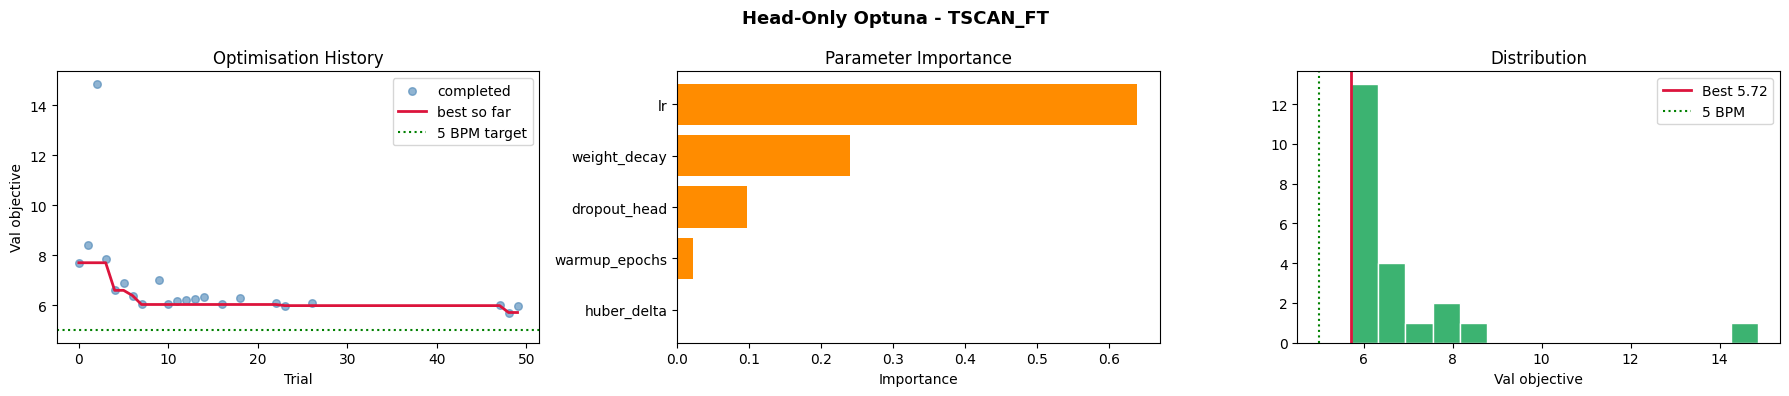

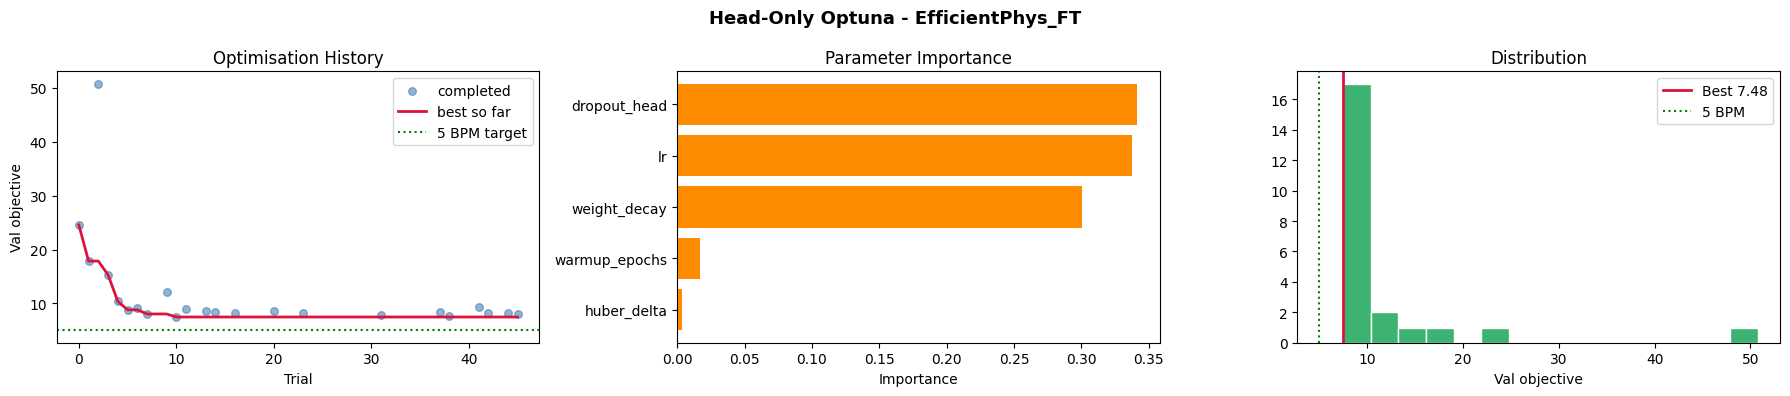

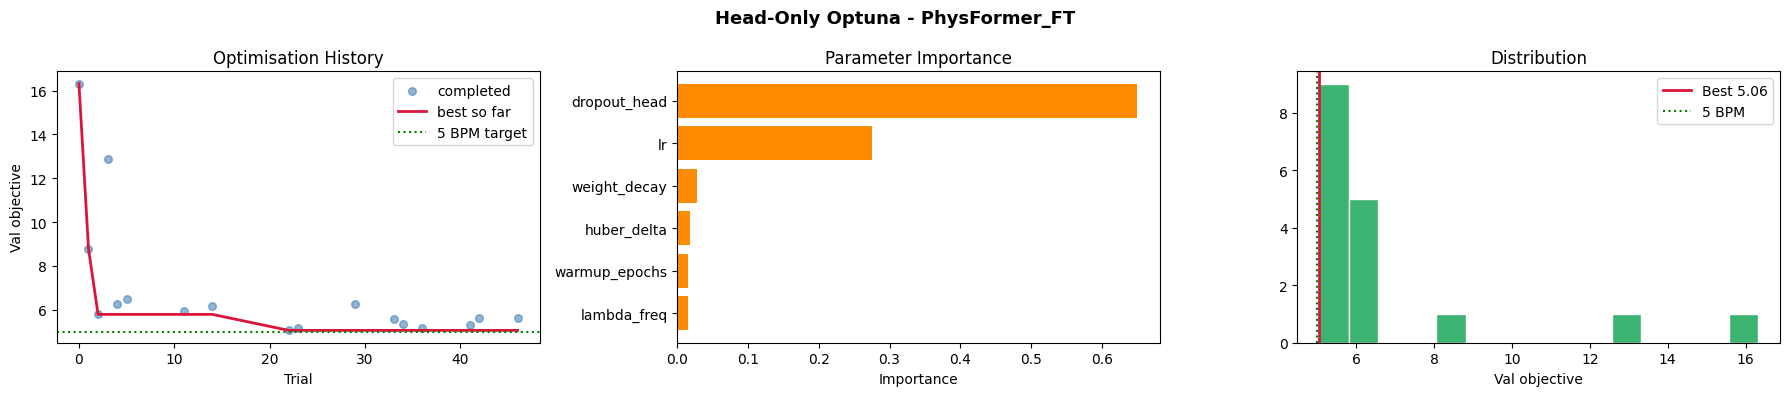

In [20]:
def plot_study(study: optuna.Study, arch_name: str) -> None:
    trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    numbers = [t.number for t in trials]
    val_maes = [t.value  for t in trials]
    best_curve = np.minimum.accumulate([t.value for t in sorted(trials, key=lambda t: t.number)])
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Head-Only Optuna - {arch_name}", fontweight="bold", fontsize=13)

    axes[0].scatter(numbers, val_maes, alpha=0.6, s=30, color="steelblue", label="completed")
    axes[0].plot(sorted(numbers), best_curve, color="crimson", linewidth=2, label="best so far")
    axes[0].axhline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Val objective")
    axes[0].set_title("Optimisation History"); axes[0].legend()

    try:
        importances = optuna.importance.get_param_importances(study)
        top = list(importances.items())[:6]
        params, imps = zip(*top)
        axes[1].barh(params, imps, color="darkorange")
        axes[1].set_xlabel("Importance"); axes[1].set_title("Parameter Importance")
        axes[1].invert_yaxis()
    except Exception:
        axes[1].text(0.5, 0.5, "Not available", ha="center", va="center", transform=axes[1].transAxes)

    axes[2].hist(val_maes, bins=15, color="mediumseagreen", edgecolor="white")
    axes[2].axvline(study.best_value, color="crimson", linewidth=2, label=f"Best {study.best_value:.2f}")
    axes[2].axvline(5.0, color="green", linestyle=":", label="5 BPM")
    axes[2].set_xlabel("Val objective"); axes[2].set_title("Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(f"optuna_headonly_{arch_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

for arch, study in [("TSCAN_FT", study_tscan),("EfficientPhys_FT", study_effphys),("PhysFormer_FT",study_physformer)]:
    plot_study(study, arch)

## 14. Retrain Best Configuration on Train + Val, Evaluate on Test

In [21]:
def retrain_and_evaluate(arch_name: str, study: optuna.Study) -> tuple:
    """
    Retrain best Optuna config on train+val, evaluate on test.
    Returns the trained model and the metrics dict.
    """    
    cfg = ARCH_REGISTRY[arch_name]
    h5_path = os.path.join(WEIGHTS_DIR, cfg["h5"])
    p = study.best_params
    best_epochs = study.best_trial.last_step
    is_physformer = arch_name == "PhysFormer_FT"

    print(f"\n{'='*55}")
    print(f"Retraining {arch_name} (head-only)")
    print(f"Best trial : #{study.best_trial.number}")
    print(f"Best epochs : {best_epochs}")
    print(f"{'='*55}")

    model = cfg["cls"](**cfg["kwargs"], dropout=p["dropout_head"], hr_min=HR_MIN, hr_max=HR_MAX).to(DEVICE)
    frac = load_pretrained_partial(model, h5_path, verbose=True)
    n_trainable = freeze_backbone(model)
    print(f"Trainable (head only) : {n_trainable:,} params")

    full_ds = CRVSEDataset(all_samples, train_keys | val_keys)
    print(f"Full train set: {len(full_ds)} windows")
    full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)

    loss_function  = nn.HuberLoss(delta=p["huber_delta"])
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()),lr=p["lr"], weight_decay=p["weight_decay"],)
    warmup_ep = p.get("warmup_epochs", 0)
    if warmup_ep > 0:
        wup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_ep)
        cos = CosineAnnealingLR(optimizer, T_max=best_epochs-warmup_ep, eta_min=p["lr"]/100)
        scheduler = SequentialLR(optimizer, [wup, cos], milestones=[warmup_ep])
    else:
        scheduler = CosineAnnealingLR(optimizer, T_max=best_epochs, eta_min=p["lr"]/100)

    lambda_freq_start = p.get("lambda_freq", 0.0)
    epoch_bar = tqdm(range(1, best_epochs+1), desc=f"Head-only {arch_name}", unit="epoch")

    for epoch in epoch_bar:
        lambda_freq = (lambda_freq_start*(1.0-(epoch-1)/best_epochs) if is_physformer else 0.0)
        model.train()
        total_loss = 0.0
        for signals, labels in full_loader:
            signals, labels = signals.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out = model(signals)
            if is_physformer and isinstance(out, tuple):
                hr_main, hr_freq = out
                loss = loss_function(hr_main, labels) + lambda_freq * loss_function(hr_freq, labels)
            else:
                loss = loss_function(out, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        epoch_bar.set_postfix({"loss": f"{total_loss/len(full_loader):.3f}"})

    # Test evaluation 
    model.eval()
    all_preds, all_labels = [], []
    with torch.inference_mode():
        for signals, labels in test_loader:
            out = model(signals.to(DEVICE))
            if isinstance(out, tuple): out = out[0]
            all_preds.extend(out.cpu().numpy().tolist())
            all_labels.extend(labels.numpy().tolist())

    preds_np = np.array(all_preds, dtype=np.float32)
    labels_np = np.array(all_labels, dtype=np.float32)
    subj_ids = [test_ds.items[i]["subject_key"] for i in range(len(test_ds))]
    ds_ids = [test_ds.items[i]["dataset"] for i in range(len(test_ds))]

    metrics = full_evaluation(preds_np, labels_np, subj_ids, ds_ids, model_name=arch_name)

    save_path = f"{arch_name}_headonly_best.pt"
    torch.save({
        "arch_name" : arch_name,
        "best_params" : study.best_params,
        "best_n_epochs" : best_epochs,
        "model_state" : model.state_dict(),
        "test_metrics" : metrics,
        "transfer_frac" : frac,
        "strategy" : "head_only",
    }, save_path)
    print(f"\nSaved -> {save_path}")
    return model, metrics

In [22]:
results: dict = {}
for arch, study in [("TSCAN_FT", study_tscan), ("EfficientPhys_FT", study_effphys),("PhysFormer_FT", study_physformer)]:
    _, metrics = retrain_and_evaluate(arch, study)
    results[arch] = metrics


Retraining TSCAN_FT (head-only)
Best trial : #48
Best epochs : 50
Pretrained transfer: 417 / 172,232 params = 0.2%
Trainable (head only) : 4,161 params
Dataset size: 8077 windows
Full train set: 8077 windows


Head-only TSCAN_FT:   0%|          | 0/50 [00:00<?, ?epoch/s]/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Head-only TSCAN_FT: 100%|██████████| 50/50 [01:12<00:00,  1.45s/epoch, loss=27.465]



FULL EVALUATION - TSCAN_FT

Window-level (n=1424 windows):
MAE : 5.33 BPM
RMSE : 7.17 BPM
MAPE : 7.22 %
Pearson r : 0.8568 (p=0.0000)
R² : 0.7318
BA bias : 0.65 LoA: [-13.36, 14.65] BPM

|error| <  5 BPM : 58.6%
|error| < 10 BPM : 86.9%
|error| < 15 BPM : 95.0%

Subject-level metrics (n=29 subjects):
MAE : 4.33 BPM
RMSE : 5.44 BPM
r : 0.9473
BA bias: 0.12  LoA: [-10.53, 10.77] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
  mcd_rppg         1174     5.07     6.70   0.6390
  ubfc_phys         175     6.30     8.79   0.5273
  ubfc_rppg          75     6.99     9.77   0.7134

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          284     7.57     9.14
normal low               833     4.26     6.16
normal high              178     7.07     8.68
tachycardia/exercise     129     4.85     5.98

Saved -> TSCAN_FT_headonly_best.pt


Head-only EfficientPhys_FT: 100%|██████████| 50/50 [01:14<00:00,  1.49s/epoch, loss=11.468]



FULL EVALUATION - EfficientPhys_FT

Window-level (n=1424 windows):
MAE : 9.56 BPM
RMSE : 12.71 BPM
MAPE : 12.37 %
Pearson r : 0.4715 (p=0.0000)
R² : 0.1580
BA bias : -0.03 LoA: [-24.95, 24.89] BPM

|error| <  5 BPM : 35.7%
|error| < 10 BPM : 62.3%
|error| < 15 BPM : 80.1%

Subject-level metrics (n=29 subjects):
MAE : 11.17 BPM
RMSE : 15.43 BPM
r : 0.7315
BA bias: -4.71  LoA: [-33.50, 24.09] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
  mcd_rppg         1174     7.68     9.43   0.1421
  ubfc_phys         175    13.30    16.08  -0.1853
  ubfc_rppg          75    30.32    32.77  -0.2790

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          284    14.94    15.37
normal low               833     4.56     5.50
normal high              178    10.59    11.33
tachycardia/exercise     129    28.60    29.85

Saved -> EfficientPhy

Head-only PhysFormer_FT: 100%|██████████| 50/50 [01:36<00:00,  1.93s/epoch, loss=20.495]



FULL EVALUATION - PhysFormer_FT

Window-level (n=1424 windows):
MAE : 6.11 BPM
RMSE : 9.17 BPM
MAPE : 7.74 %
Pearson r : 0.7600 (p=0.0000)
R² : 0.5615
BA bias : 0.69 LoA: [-17.24, 18.62] BPM

|error| <  5 BPM : 58.4%
|error| < 10 BPM : 83.1%
|error| < 15 BPM : 91.0%

Subject-level metrics (n=29 subjects):
MAE : 5.31 BPM
RMSE : 9.23 BPM
r : 0.8434
BA bias: -1.18  LoA: [-19.12, 16.76] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
  mcd_rppg         1174     4.59     6.24   0.7234
  ubfc_phys         175     9.93    12.41   0.3357
  ubfc_rppg          75    20.90    25.08  -0.2472

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          284     6.48     8.88
normal low               833     4.36     6.16
normal high              178     7.25     9.04
tachycardia/exercise     129    15.01    19.94

Saved -> PhysFormer_FT_headon

## 15. Three-Way Comparison Table

**Full Fine-Tune** - **Head-Only** - **Scratch-Trained**

In [23]:
print("\n" + "=" * 95)
print("THREE-WAY COMPARISON: Head-Only vs Full Fine-Tune vs Scratch-Trained")
print("=" * 95)
print(f"{'Model':<28} {'Strategy':<14} {'Win MAE':>9} {'Subj MAE':>9} {'r':>8} {'BA bias':>9} {'R²':>7}")
print("  " + "─" * 80)

# Head-Only (this notebook)
for arch_name, m in results.items():
    print(f"{arch_name:<28} {'head-only':<14} {m['window_mae']:>9.2f} "
          f"{m['subj_mae']:>9.2f} {m['subj_r']:>8.4f} {m['ba_bias']:>9.2f} {m['r2']:>7.4f}")

print("  " + "─" * 80)

# Full Fine-Tune 
print("[FULL FINE-TUNE]")
nb1 = [
    ("TSCAN_FT", 3.78, 2.98, 0.9760, -0.98,  0.8489),
    ("EfficientPhys_FT", 11.95, 12.39, 0.9770, 11.86, 0.0874),
    ("PhysFormer_FT", 3.38, 2.21, 0.9816, -0.43, 0.8560),
]
for name, wm, sm, r, ba, r2 in nb1:
    print(f"{name:<28} {'full-ft':<14} {wm:>9.2f} {sm:>9.2f} {r:>8.4f} {ba:>9.2f} {r2:>7.4f}")

print("  " + "─" * 80)

# Scratch 
print("[SCRATCH]")
scratch = [
    ("CRVSENet (R1)", 3.06, 2.37, 0.9300, -1.27, 0.8887),
    ("CRVSEPhysFormer (R3)", 3.15, 2.35, 0.9320 , +1.78, 0.8452),
    ("CRVSEResNetSE (R4)",  2.82, 2.10, 0.9573, -1.49, 0.9037),
]
for name, wm, sm, r, ba, r2 in scratch:
    r2_str = f"{r2:.4f}" if r2 else "  —  "
    print(f" {name:<28} {'scratch':<14} {wm:>9.2f} {sm:>9.2f} {r:>8.4f} {ba:>9.2f} {r2_str:>7}")

print("=" * 95)
print()
print("Strategy comparison guide:")
print(" head-only -> backbone frozen, only regression head trained (~2–10k params)")
print("full-ft -> all layers trained, backbone lr < head lr")
print("scratch -> random init, architecture search (Optuna over structure + training HPs)")
print()
print("Key questions this table answers:")
print("1. Does frozen backbone (head-only) outperform fully-trained scratch? -> architecture transfer")
print("2. Does full fine-tuning beat head-only? -> backbone adaptation value")
print("3. Which strategy is most robust across architectures?")



THREE-WAY COMPARISON: Head-Only vs Full Fine-Tune vs Scratch-Trained
Model                        Strategy         Win MAE  Subj MAE        r   BA bias      R²
  ────────────────────────────────────────────────────────────────────────────────
TSCAN_FT                     head-only           5.33      4.33   0.9473      0.12  0.7318
EfficientPhys_FT             head-only           9.56     11.17   0.7315     -4.71  0.1580
PhysFormer_FT                head-only           6.11      5.31   0.8434     -1.18  0.5615
  ────────────────────────────────────────────────────────────────────────────────
[FULL FINE-TUNE]
TSCAN_FT                     full-ft             3.78      2.98   0.9760     -0.98  0.8489
EfficientPhys_FT             full-ft            11.95     12.39   0.9770     11.86  0.0874
PhysFormer_FT                full-ft             3.38      2.21   0.9816     -0.43  0.8560
  ────────────────────────────────────────────────────────────────────────────────
[SCRATCH]
 CRVSENet (R1)   

## Conclusions

### Head-Only Transfer: Weakest Strategy Across All Architectures

Freezing the backbone and training only the regression head (2–7k params) consistently underperforms both full fine-tuning and scratch training. The frozen 3D-pretrained backbone produces representations that are misaligned with 1D rPPG signals - the head cannot compensate for this gap with so few trainable parameters.


### Full Fine-Tune vs Head-Only: Backbone Adaptation is Non-Negotiable

Full fine-tuning outperforms head-only in every case, with the gap largest where
architectural mismatch is most severe:

| Model | Head-only Subj MAE | Full-FT Subj MAE | Recovery |
|---|---|---|---|
| TSCAN_FT | 4.33 | 2.98 | +1.35 BPM |
| EfficientPhys_FT | 11.17 | 12.39 | −1.22 BPM (worse) |
| PhysFormer_FT | 5.31 | 2.21 | +3.10 BPM |

EfficientPhys is the exception - full fine-tuning makes it *worse* (12.39 vs 11.17 BPM), replacing near-zero bias (−0.03) with a large systematic offset (+11.86 BPM). This is a pathological case: the backbone adapts but introduces a fixed HR shift the head cannot correct, suggesting the 3D -> 1D spatial collapse destroys the feature structure EfficientPhys depends on.

---

### No Transfer Strategy Beats the Best Scratch Model

CRVSEResNetSE (scratch, Subj MAE 2.10 BPM, r = 0.9573) remains the Phase A+ leader. The closest fine-tuned result is PhysFormer_FT full-ft at 2.21 BPM - competitive but not superior, and achieved only with full backbone gradient flow on 172k->235k parameter models vs CRVSEResNetSE's purpose-built 1D architecture.

---

### Overall Finding

**Architecture design transfers. Pretrained 3D weights do not - given the 3D -> 1D domain gap.**

The decisive differentiator across all strategies and architectures is **PhysFormer's frequency-domain supervision anchor**: it enables stable training under high backbone LR, suppresses systematic HR over/underestimation, and remains effective whether the model is trained from scratch, fully fine-tuned, or head-only. No other architecture maintains this robustness across all three strategies.

EfficientPhys's failure mode - high correlation with catastrophic bias in full fine-tuning, complete correlation collapse in head-only - confirms that spectral supervision, not parameter count or backbone depth, is the critical ingredient for reliable 1D rPPG regression.
